In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'data').exists():
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

for candidate in [
    PROJECT_ROOT / 'code',
    PROJECT_ROOT / 'code' / 'revenue',
    PROJECT_ROOT / 'code' / 'tmdb',
]:
    if candidate.exists() and str(candidate.resolve()) not in sys.path:
        sys.path.append(str(candidate.resolve()))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold

from experiment_utils import (
    ARTICLE_FIGURE_SIZES,
    FOLDS_PATH,
    RANDOM_SEED,
    STRATIFICATION_BINS_PATH,
    apply_article_figure_theme,
    load_processed_movies,
    show_and_save_current_figure,
)

In [2]:
RANDOM_SEED = 222050006
NOTEBOOK_IMAGE_PREFIX = '01_fold_generation'

# **Geração dos Folds de Revenue**

Este notebook define o protocolo de validação externa usado em toda a etapa de regressão. A partir da base já processada, a coluna `revenue` é discretizada em faixas com `pd.qcut`, os 10 folds estratificados são gerados com `StratifiedKFold` e os artefatos resultantes são persistidos em `data/` para reutilização nos demais notebooks.

Como todos os experimentos posteriores dependem dessa mesma separação entre treino e teste, esta etapa funciona como a referência de reprodutibilidade do pipeline.


In [3]:
df_movies = load_processed_movies()

In [4]:
df_movies

,id_tmdb,title,runtime,adult,belongs_to_collection,budget,Action,Adventure,Animation,Comedy,...,sv,ta,te,th,tn,tr,uk,ur,zh,revenue
0,552524,Lilo & Stitch,108,0,0,100000000,0,0,0,1,...,0,0,0,0,0,0,0,0,0,610800000
1,950387,A Minecraft Movie,101,0,1,150000000,0,1,0,1,...,0,0,0,0,0,0,0,0,0,947000000
2,1257960,सिकंदर,133,0,0,23500000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,24727058
3,574475,Final Destination Bloodlines,110,0,1,50000000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,229314062
4,1197306,A Working Man,116,0,0,40000000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,98652557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6913,12211,Highlander: Endgame,87,0,1,25000000,1,1,0,0,...,0,0,0,0,0,0,0,0,0,15843608
6914,590706,Jiu Jitsu,102,0,0,23000000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,99924
6915,459616,Alad'2,98,0,1,18900000,0,1,0,1,...,0,0,0,0,0,0,0,0,0,19000000
6916,188207,The Legend of Hercules,99,0,0,70000000,1,1,0,0,...,0,0,0,0,0,0,0,0,0,61279452


## **Faixas de Estratificação**

A distribuição de `revenue` é contínua e bastante assimétrica, o que inviabiliza uma estratificação direta sobre o valor bruto. Por isso, o notebook transforma a variável-alvo em intervalos com `pd.qcut`, criando grupos com frequências semelhantes e reduzindo o risco de folds muito desbalanceados.

Esses rótulos são usados apenas para balancear as partições. A variável-alvo original continua intacta e segue sendo exatamente a quantidade prevista pelos modelos de regressão.


In [5]:
n_bins = 5
stratify_labels, bins = pd.qcut(
    df_movies['revenue'],
    q=n_bins,
    labels=False,
    retbins=True,
    duplicates='drop'
)

print(bins)

[1.00000000e+00 7.09000000e+06 2.24626998e+07 5.28200000e+07
 1.34075202e+08 2.92370603e+09]


Figura: Distribuicao de Revenue com cortes do pd.qcut (Eixo X em escala log)


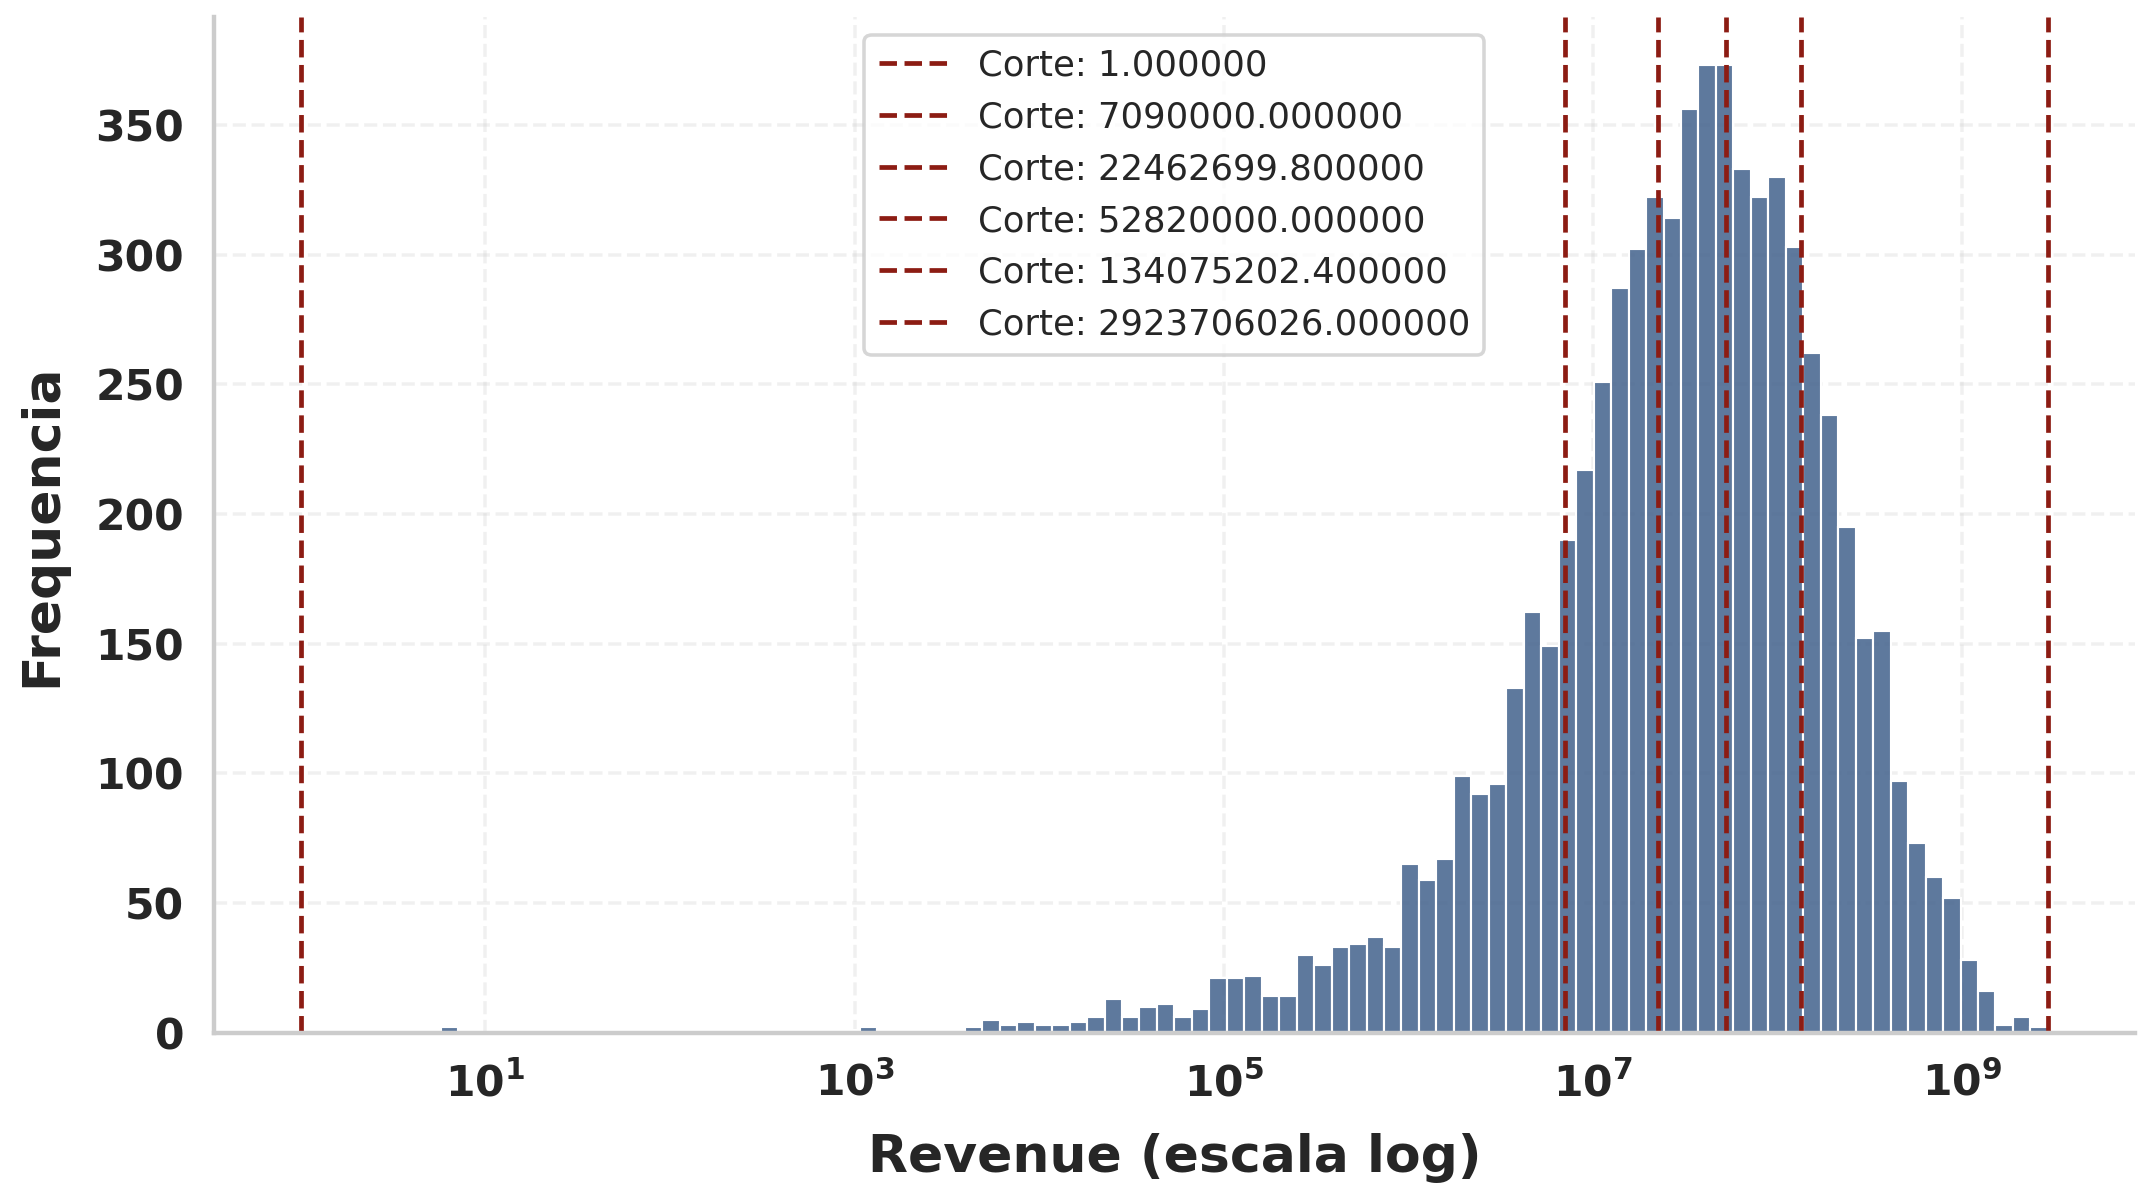

PosixPath('/home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina/trabalho_pratico_1/code/revenue/images/01_fold_generation_distribuicao_revenue_com_cortes_pd_qcut.png')

In [6]:
figure_title = 'Distribuicao de Revenue com cortes do pd.qcut (Eixo X em escala log)'
apply_article_figure_theme()
plt.figure(figsize=(13, 7.4))

ax = sns.histplot(
    df_movies['revenue'],
    bins=100,
    color='#4c6a92',
    edgecolor='white',
    linewidth=0.9,
    alpha=0.9,
    log_scale=(True, False)
)

for b in bins:
    if b > 0:
        plt.axvline(x=b, color='#8c1c13', linestyle='--', linewidth=2.0, label=f'Corte: {b:.6f}')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), fontsize=ARTICLE_FIGURE_SIZES['legend'], title_fontsize=ARTICLE_FIGURE_SIZES['legend_title'])

plt.xlabel('Revenue (escala log)', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=12)
plt.ylabel('Frequencia', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=12)
ax.tick_params(axis='x', labelsize=ARTICLE_FIGURE_SIZES['tick'])
ax.tick_params(axis='y', labelsize=ARTICLE_FIGURE_SIZES['tick'])
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('semibold')
ax.grid(True, linestyle='--', alpha=0.28)
sns.despine(ax=ax)

plt.tight_layout()
show_and_save_current_figure(
    f'{NOTEBOOK_IMAGE_PREFIX}_distribuicao_revenue_com_cortes_pd_qcut',
    notebook_title=figure_title,
)

## **Geração e Salvamento**

Os folds são salvos por `id_tmdb`, o que permite reconstruir com segurança os subconjuntos de treino e teste mesmo que a ordem das linhas mude em outros notebooks. Os limites calculados por `pd.qcut` também são persistidos, documentando o critério de estratificação e garantindo que comparações futuras usem exatamente o mesmo protocolo experimental.


In [7]:
if not df_movies['id_tmdb'].is_unique:
    raise ValueError('A coluna id_tmdb precisa ser unica para salvar os folds por identificador.')

X = df_movies.drop(columns=['id_tmdb', 'title', 'revenue'])
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

fold_assignments = pd.Series(index=df_movies.index, dtype='int64', name='fold')

for fold, (_, test_index) in enumerate(skf.split(X, stratify_labels)):
    fold_assignments.iloc[test_index] = fold

fold_assignments_df = (
    pd.DataFrame({
        'id_tmdb': df_movies['id_tmdb'],
        'fold': fold_assignments.astype(int)
    })
    .sort_values('id_tmdb')
    .reset_index(drop=True)
)

fold_assignments_df.to_csv(FOLDS_PATH, index=False)
pd.DataFrame({'bin_edge': bins}).to_csv(STRATIFICATION_BINS_PATH, index=False)

print('Arquivos salvos: data/revenue_folds.csv e data/revenue_stratification_bins.csv')
fold_assignments_df.head()

Arquivos salvos: data/revenue_folds.csv e data/revenue_stratification_bins.csv


,id_tmdb,fold
0,5,1
1,6,0
2,11,4
3,12,2
4,13,4


In [8]:
fold_assignments_df.groupby('fold').size().rename('n_movies').reset_index()

,fold,n_movies
0,0,692
1,1,692
2,2,692
3,3,692
4,4,692
5,5,692
6,6,692
7,7,692
8,8,691
9,9,691
